In [6]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import psutil # Pastikan sudah install: pip install psutil

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [7]:
# 1. LOAD DATA
df = pd.read_excel('#1 final feature selected dataset 6 for boiler efficiency.xlsx')
X = df.drop(columns=['Boiler Eff (%)'])
y = df['Boiler Eff (%)']


In [8]:
df

,Reheat steam pressure (turbine side) (MPa),Coal Flow (t/h),Refference Temperature (°C),CO (mg/nm3),Velocity (m/s),Cold Reheat Temperature (°C),Dust (mg/nm3),HHV (Kcal/Kg),Condenser vacuum (kPa),Temperature HRH,Opacity (%),Pressure (Kpa),Boiler Eff (%)
0,2.244045,192.41,35.0,675.494230,13.543683,322.19,0.269452,4389.444444,-93.254772,566.36,49.690183,-0.268340,77.915748
1,2.062675,181.37,33.0,677.919792,12.093034,320.50,0.270812,4389.444444,-93.319363,565.00,49.691542,-0.254642,76.294873
2,2.063605,178.47,33.0,679.644721,11.900385,320.80,0.272701,4389.444444,-93.313517,565.63,49.697809,-0.248897,77.886219
3,2.004410,172.09,33.0,682.033313,11.613680,321.34,0.274674,4389.444444,-93.346417,564.09,49.702891,-0.225933,78.367624
4,2.103664,181.74,34.0,478.544209,12.103985,320.44,0.283205,4389.444444,-93.245120,565.75,49.688853,-0.235743,77.856369
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,2.199774,172.99,27.0,791.996076,12.955925,320.61,7.591082,4237.333333,-92.739841,565.60,49.763117,-0.287959,89.855113
545,2.036869,164.77,27.5,792.244088,12.270126,322.63,7.572601,4237.333333,-92.818141,565.79,49.763391,-0.221320,88.052730
546,2.019442,169.38,27.5,792.396151,12.097462,323.38,7.570885,4237.333333,-93.038286,565.84,49.768304,-0.106860,85.018900
547,2.097743,179.69,28.0,791.685285,12.569459,323.13,7.570648,4237.333333,-92.750339,566.30,49.766662,-0.113589,83.295960


In [9]:
# 2. SETUP EKSPERIMEN
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
training_times = []
inference_times = []



In [10]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
print(f"{'N':<8} | {'Train Time (s)':<15} | {'Inf Time (s)':<15}")
print("-" * 45)

# 3. LOOPING PENGUKURAN
for prop in sample_sizes:
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    n_records.append(n)

    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    
    # --- PENGUKURAN TRAINING ---
    start_train = time.time()
    model.fit(X_subset, y_subset)
    end_train = time.time()
    training_times.append(end_train - start_train)

    # --- PENGUKURAN INFERENCE (DETEKSI) ---
    start_inf = time.time()
    model.predict(X_subset)
    end_inf = time.time()
    inference_times.append(end_inf - start_inf)

    print(f"{n:<8} | {training_times[-1]:<15.4f} | {inference_times[-1]:<15.4f}")

N        | Train Time (s)  | Inf Time (s)   
---------------------------------------------
54       | 4.1379          | 0.0261         
109      | 4.5009          | 0.0270         
164      | 5.7085          | 0.0335         
219      | 6.2769          | 0.0378         
274      | 8.1565          | 0.0428         
329      | 8.4154          | 0.0485         
384      | 8.3944          | 0.0499         
439      | 9.2870          | 0.0630         
494      | 11.7441         | 0.0634         
549      | 12.2825         | 0.0712         


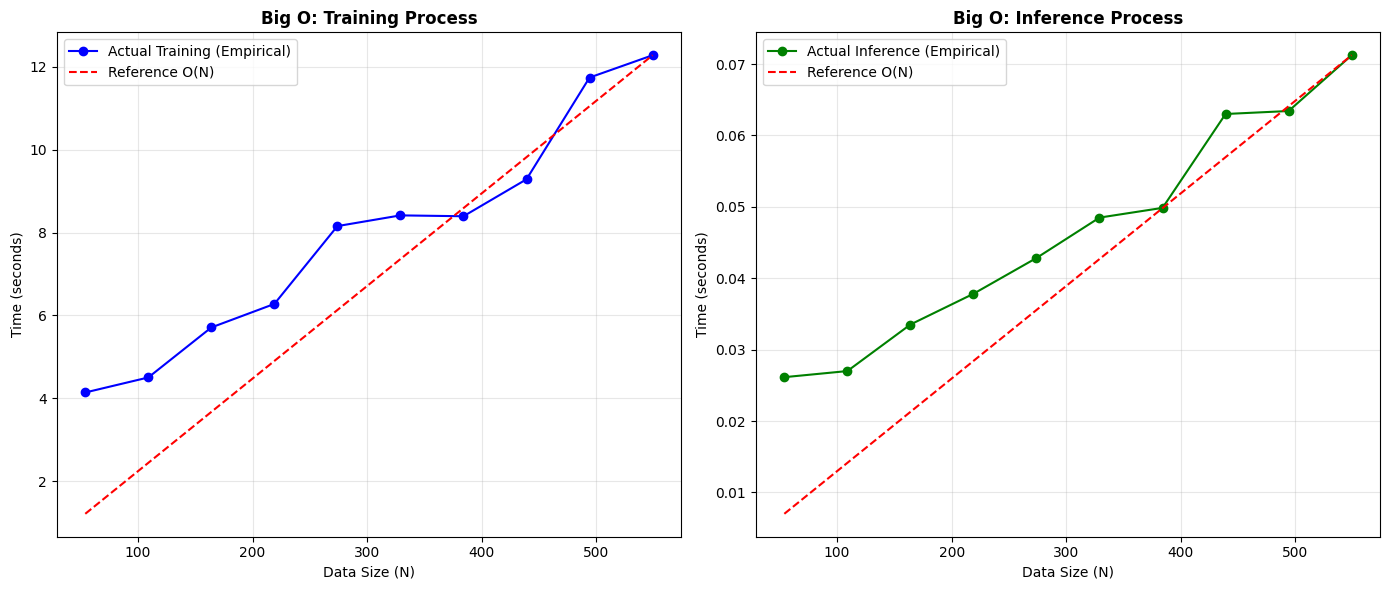

In [11]:
# 4. VISUALISASI PERBANDINGAN BIG O
plt.figure(figsize=(14, 6))

# Subplot 1: Training
plt.subplot(1, 2, 1)
plt.plot(n_records, training_times, 'bo-', label='Actual Training (Empirical)')
train_linear = [training_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, train_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Training Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Inference
plt.subplot(1, 2, 2)
plt.plot(n_records, inference_times, 'go-', label='Actual Inference (Empirical)')
inf_linear = [inference_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, inf_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Inference Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()